# Computational Gastronomy — Assignment 1 — Question 3

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("data")
OUT_DIR = Path("q3_output")
OUT_DIR.mkdir(exist_ok=True)

BLUE = "#2a78d6"

# (Recipe ID, Ingredient Name) table produced in Q1(c)
pairs = pd.read_csv(DATA_DIR / "recipe_id_ingredient_name.csv")
print("Loaded", len(pairs), "(recipe_id, ingredient_name) rows covering",
      pairs["recipe_id"].nunique(), "recipes")
pairs.head()

Loaded 98309 (recipe_id, ingredient_name) rows covering 10000 recipes


,recipe_id,ingredient_name
0,1,seedless orange
1,1,lemon
2,1,olive oil
3,1,almonds
4,1,polenta


## Q3(a) — Frequency-rank distribution

In [2]:
ingredient_freq = pairs["ingredient_name"].value_counts()

ranks = np.arange(1, len(ingredient_freq) + 1)
frequencies = ingredient_freq.values

print(f"{len(ingredient_freq)} unique ingredients")
print(f"rank 1 (most frequent): {ingredient_freq.index[0]!r} with {frequencies[0]} occurrences")
print(f"rank {len(ingredient_freq)} (least frequent): {ingredient_freq.index[-1]!r} with {frequencies[-1]} occurrence(s)")

13825 unique ingredients
rank 1 (most frequent): 'olive oil' with 2732 occurrences
rank 13825 (least frequent): 'soft wholemeal rolls' with 1 occurrence(s)


Saved -> q3_output/q3a_frequency_rank_distribution.png


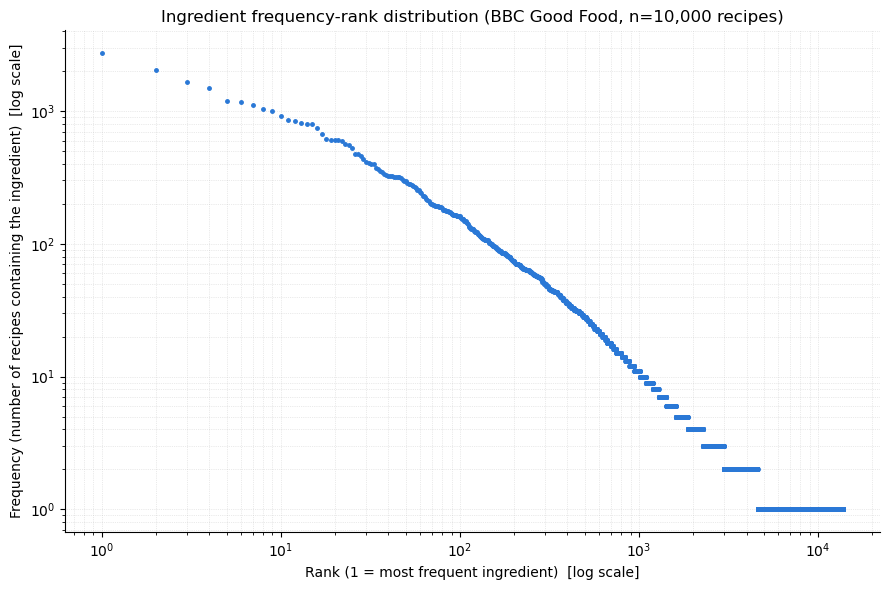

In [3]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(ranks, frequencies, marker="o", markersize=2.5, linestyle="none", color=BLUE)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Ingredient frequency-rank distribution (BBC Good Food, n=10,000 recipes)")
ax.set_xlabel("Rank (1 = most frequent ingredient)  [log scale]")
ax.set_ylabel("Frequency (number of recipes containing the ingredient)  [log scale]")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, which="both", linestyle=":", linewidth=0.5, alpha=0.5)
fig.tight_layout()

out_path = OUT_DIR / "q3a_frequency_rank_distribution.png"
fig.savefig(out_path, dpi=150)
print(f"Saved -> {out_path}")
plt.show()

In [4]:
# Also save the underlying (rank, ingredient, frequency) table used for the plot
rank_table = pd.DataFrame({
    "rank": ranks,
    "ingredient_name": ingredient_freq.index,
    "frequency": frequencies,
})
table_path = OUT_DIR / "q3a_frequency_rank_table.csv"
rank_table.to_csv(table_path, index=False)
print(f"Saved -> {table_path}")
rank_table.head(10)

Saved -> q3_output/q3a_frequency_rank_table.csv


,rank,ingredient_name,frequency
0,1,olive oil,2732
1,2,butter,2045
2,3,flour,1669
3,4,eggs,1494
4,5,garlic,1201
5,6,onion,1170
6,7,caster sugar,1104
7,8,milk,1029
8,9,golden caster sugar,997
9,10,garlic clove,917


## Files produced

- `q3_output/q3a_frequency_rank_distribution.png`
- `q3_output/q3a_frequency_rank_table.csv`